# Predicción del nivel de comisiones por bloque en la red Bitcoin

Proyecto Final de Machine Learning (CS3061) — UTEC, 2026-2
**Etapa 1: formulación del problema, descripción del dataset y análisis exploratorio.**

---

## 1. El problema

Cuando una persona emite una transacción en Bitcoin debe elegir cuánta comisión ofrece a los
mineros. Esa elección determina si la transacción se confirma pronto o permanece en espera:

- Si ofrece **poco**, la transacción puede tardar horas o días en confirmarse, o no confirmarse.
- Si ofrece **de más**, paga un sobrecosto innecesario que no puede recuperar, porque las
  transacciones en Bitcoin son irreversibles.

El espacio en un bloque es limitado y los mineros seleccionan qué transacciones incluyen. Cuando
la demanda supera esa capacidad, se forma una subasta: los usuarios compiten ofreciendo
comisiones mayores. El precio resultante varía de forma considerable en cuestión de horas.

Las carteras incorporan estimadores de comisión para asistir esta decisión, pero su desempeño es
limitado, sobre todo en los episodios de mayor congestión, que son justamente aquellos en los que
el usuario más necesita una estimación correcta.

## 2. Objetivo

Determinar si, a partir del estado observable de la red hasta el bloque actual, es posible
anticipar si la comisión del siguiente bloque será **alta respecto al nivel vigente del mercado**.

El resultado no constituye un estimador de comisión completo, sino su primer componente: la
estimación del nivel de precio del mercado, sobre la cual un estimador operativo aplicaría después
el criterio de urgencia de cada usuario.

## 3. Formulación como problema de aprendizaje (E, T, P)

**Tarea (T).** Clasificación binaria. Dado el bloque *t* y su historia, predecir si la tasa
mediana de comisión del bloque *t+1* superará el percentil 75 de los bloques recientes.

**Experiencia (E).** 810 908 pares (bloque, bloque siguiente) construidos a partir del registro
histórico de la cadena de bloques de Bitcoin entre enero de 2009 y octubre de 2023. Cada bloque
aporta trece atributos observables en el momento de su publicación: altura, marca de tiempo,
tamaño, número de transacciones, dificultad de minería, tasas de comisión mediana, promedio,
mínima y máxima, comisiones totales, número de entradas y de salidas, y valor total de salidas.

**Medida de desempeño (P).** F1 sobre la clase «alta» y área bajo la curva de precisión-cobertura
(PR-AUC), evaluadas sobre una partición temporal posterior a la de entrenamiento. No se emplea la
exactitud como métrica principal: con clases desbalanceadas, un clasificador que prediga siempre
la clase mayoritaria obtiene valores altos sin capacidad predictiva. Toda comparación se realiza
contra una referencia de persistencia, que predice para el bloque *t+1* la clase observada en *t*.

## 4. Alcance: qué se predice y qué no

Estas delimitaciones se derivan de la naturaleza de los datos disponibles y condicionan la
interpretación de cualquier resultado.

- **Se predice el nivel de comisión, no la ocupación del bloque.** La ocupación es la condición
  que da origen al mercado de comisiones, y se analiza en la sección 11.1 con ese propósito, pero
  no es la variable objetivo.
- **Se modela el mercado agregado, no la decisión individual.** La unidad de observación es el
  bloque, que resume cientos o miles de transacciones. El conjunto de datos no contiene el
  historial de transacciones individuales, por lo que no es posible estimar la probabilidad de
  inclusión de una transacción concreta.
- **Los datos describen transacciones confirmadas.** Las transacciones que ofrecieron comisiones
  insuficientes y nunca se incluyeron en un bloque no aparecen en el registro. Se observa el
  resultado de la subasta, no el conjunto de ofertas.
- **No se dispone del estado del mempool.** La cola de transacciones pendientes es un estado
  transitorio que no puede reconstruirse retrospectivamente. La congestión se aproxima mediante la
  ocupación de los bloques y las propias tasas observadas.

## 5. Preguntas de investigación

1. ¿La tasa de comisión del bloque actual permite anticipar la del siguiente por encima de lo que
   logra una regla de persistencia?
2. ¿Qué atributos del estado de la red aportan información adicional a la tasa reciente?
3. ¿El desempeño del clasificador se mantiene estable a lo largo del periodo estudiado, o varía
   entre tramos con distinto nivel de congestión?

## 6. Hipótesis

- **H1.** La tasa de comisión reciente es el predictor dominante, dada la persistencia observada
  en series de esta naturaleza.
- **H2.** Los atributos de actividad de la red —número de transacciones y comisiones totales—
  aportan una mejora marginal sobre H1, menor que la contribución de la propia tasa.
- **H3.** El desempeño es menor en los tramos del periodo donde la comisión no se determinaba por
  competencia entre usuarios.

## 7. Plan de trabajo

**Etapa 1 (este documento).** Descripción del conjunto de datos, revisión de su calidad, análisis
exploratorio, definición y validación de la variable objetivo, y diseño de la partición
experimental. No se entrenan modelos.

**Etapa 2.** Construcción de variables derivadas, entrenamiento de una referencia de persistencia
y de modelos de clasificación, validación con ventana expansiva y evaluación segmentada por nivel
de congestión. El detalle figura en la sección 13.

---

## 8. Conjunto de datos

Cada fila del conjunto de datos representa un **bloque** de la cadena. Se emplea el registro
completo disponible, de enero de 2009 a octubre de 2023, sin restringir el periodo: el volumen y
la diversidad de condiciones de red que aporta resultan de interés para evaluar la estabilidad del
comportamiento a lo largo del tiempo. La sección 11.1 caracteriza esa heterogeneidad y la sección
14 la recoge como limitación.

Fuente: Jesús Graterol, [Bitcoin Blockchain Historical Data](https://www.kaggle.com/datasets/jesusgraterol/bitcoin-blockchain-dataset), Kaggle.

### 8.1 Importar las librerías

Pandas permite trabajar con tablas y Matplotlib crear gráficos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


### 8.2 Cargar y observar el dataset

El notebook y `dataset.csv` están en la misma carpeta. Se ejecuta desde `eda/`.


In [2]:
df = pd.read_csv("dataset.csv")
df.head()


,height,timestamp,size,tx_count,difficulty,median_fee_rate,avg_fee_rate,total_fees,fee_range_min,fee_range_max,input_count,output_count,output_amount
0,1,1231469665000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
1,2,1231469744000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
2,3,1231470173000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
3,4,1231470988000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
4,5,1231471428000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0


In [3]:
print("Filas y columnas:", df.shape)
df.info()


Filas y columnas: (810909, 13)
<class 'pandas.DataFrame'>
RangeIndex: 810909 entries, 0 to 810908
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   height           810909 non-null  int64  
 1   timestamp        810909 non-null  int64  
 2   size             810909 non-null  int64  
 3   tx_count         810909 non-null  int64  
 4   difficulty       810909 non-null  float64
 5   median_fee_rate  810909 non-null  float64
 6   avg_fee_rate     810909 non-null  int64  
 7   total_fees       810909 non-null  int64  
 8   fee_range_min    810909 non-null  float64
 9   fee_range_max    810909 non-null  float64
 10  input_count      810909 non-null  int64  
 11  output_count     810909 non-null  int64  
 12  output_amount    810909 non-null  int64  
dtypes: float64(4), int64(9)
memory usage: 80.4 MB


### 8.3 Descripción de las variables

| Columna | Significado |
|---|---|
| `height` | Altura: posición del bloque en la cadena, desde el bloque génesis |
| `timestamp` | Momento de minado del bloque, como marca de tiempo Unix en milisegundos |
| `size` | Tamaño del bloque en bytes |
| `tx_count` | Número de transacciones incluidas en el bloque |
| `difficulty` | Dificultad de minería vigente, ajustada por el protocolo cada 2016 bloques |
| `median_fee_rate` | **Variable de interés.** Mediana de las tasas de comisión pagadas por las transacciones incluidas en el bloque, en satoshis por byte |
| `avg_fee_rate` | Promedio de las tasas de comisión pagadas por las transacciones del bloque |
| `total_fees` | Suma de las comisiones recaudadas por el minero del bloque, en satoshis |
| `fee_range_min` | Tasa de comisión más baja pagada por una transacción del bloque |
| `fee_range_max` | Tasa de comisión más alta pagada por una transacción del bloque |
| `input_count` | Número total de entradas de todas las transacciones del bloque |
| `output_count` | Número total de salidas de todas las transacciones del bloque |
| `output_amount` | Valor total de todas las salidas del bloque, en satoshis |

**Sobre `median_fee_rate`.** Un bloque contiene cientos o miles de transacciones, cada una con su
propia comisión. Esta columna toma el valor central de esa distribución. Se interpreta como el
precio aproximado que era necesario ofrecer para que una transacción fuese incluida en ese bloque:
si vale 20, una transacción que ofreciera alrededor de 20 satoshis por byte tenía posibilidades
razonables de entrar.

El objetivo del proyecto se construye a partir de esta columna, desplazada un bloque hacia
adelante.

Las entradas y salidas no representan personas ni cuentas únicas: una misma transacción puede
tener varias de cada una.

## 9. Calidad de los datos

### 9.1 Valores faltantes y duplicados

Estas revisiones iniciales describen la calidad del archivo completo.


In [4]:
df.isna().sum()

height             0
timestamp          0
size               0
tx_count           0
difficulty         0
median_fee_rate    0
avg_fee_rate       0
total_fees         0
fee_range_min      0
fee_range_max      0
input_count        0
output_count       0
output_amount      0
dtype: int64

In [5]:
datos_completos = df.copy()

print("Filas duplicadas:", df.duplicated().sum())
print("Alturas repetidas:", df["height"].duplicated().sum())
print("Valores negativos por columna:")
df.lt(0).sum()

Filas duplicadas: 0
Alturas repetidas: 0
Valores negativos por columna:


height             0
timestamp          0
size               0
tx_count           0
difficulty         0
median_fee_rate    0
avg_fee_rate       0
total_fees         0
fee_range_min      0
fee_range_max      0
input_count        0
output_count       0
output_amount      0
dtype: int64

### 9.2 Coherencia interna de las tasas

Por definición, la mediana de un conjunto de valores debe situarse entre su mínimo y su máximo. Se
verifica que `median_fee_rate` esté contenida en el intervalo `[fee_range_min, fee_range_max]` del
mismo bloque.

In [6]:
fuera_de_rango = ((datos_completos["median_fee_rate"] < datos_completos["fee_range_min"]) |
                  (datos_completos["median_fee_rate"] > datos_completos["fee_range_max"]))

print("Bloques con mediana fuera del rango publicado:", fuera_de_rango.sum())
print("Porcentaje:", round(fuera_de_rango.mean() * 100, 2))
print("Bloques con promedio por encima del máximo:",
      (datos_completos["avg_fee_rate"] > datos_completos["fee_range_max"]).sum())

Bloques con mediana fuera del rango publicado: 2512
Porcentaje: 0.31
Bloques con promedio por encima del máximo: 0


2 512 bloques (0,31 %) presentan una mediana fuera del rango publicado, situación
imposible si las tres columnas describieran el mismo conjunto de transacciones. El promedio,
en cambio, nunca supera el máximo.

La inconsistencia proviene de la fuente y no de esta copia. Se documenta y se conservan las
filas; si esas columnas se utilizaran como variables de entrada en la etapa 2, convendría
excluir los bloques afectados o tratarlos por separado.

En esta copia no se encontraron nulos, duplicados ni valores negativos. Por ello, no se necesita
rellenar datos ni eliminar filas por esos motivos. Esto no garantiza que todas las mediciones estén
libres de problemas.

## 10. Construcción del objetivo y partición experimental

Se ordena por `height`. Las fechas registradas pueden retroceder entre bloques consecutivos: el
protocolo admite que la marca de tiempo de un bloque sea anterior a la del precedente siempre que
supere la mediana de los once bloques previos. No representan tiempos de espera de una
transacción.

In [7]:
df = df.sort_values("height").reset_index(drop=True)

print("Saltos de altura distintos de 1:", df["height"].diff().dropna().ne(1).sum())
print("Retrocesos del timestamp:", df["timestamp"].diff().lt(0).sum())

assert df["height"].diff().dropna().eq(1).all()


Saltos de altura distintos de 1: 0
Retrocesos del timestamp: 14572


Para cada bloque se toma la tasa del siguiente con `shift(-1)`. Cada fila queda así asociada al
valor que se busca anticipar: los atributos corresponden al bloque observado y el objetivo, al
bloque posterior. La última fila no tiene un bloque siguiente observado, así que se excluye.

La partición es **temporal**: 70 % de entrenamiento, 15 % de validación y 15 % de prueba, sin
mezclar el orden. Una partición aleatoria permitiría entrenar con bloques posteriores a los
evaluados, lo que constituiría fuga de información. A partir de aquí, el análisis utiliza **solo
entrenamiento**; las revisiones anteriores del archivo completo fueron estructurales.

In [8]:
df["tasa_siguiente"] = df["median_fee_rate"].shift(-1)
datos = df.iloc[:-1].copy()

corte_train = int(len(datos) * 0.70)
corte_val = int(len(datos) * 0.85)

train = datos.iloc[:corte_train].copy()
validacion = datos.iloc[corte_train:corte_val].copy()
prueba = datos.iloc[corte_val:].copy()

print("Pares de entrenamiento:", len(train))
print("Pares de validación:", len(validacion))
print("Pares de prueba:", len(prueba))


Pares de entrenamiento: 567635
Pares de validación: 121636
Pares de prueba: 121637


## 11. Estadísticas descriptivas

`describe()` muestra cantidad, media, desviación estándar, mínimo, cuartiles y máximo. Las tasas y comisiones tienen valores máximos muy alejados de su mediana; conviene revisar esa asimetría en los gráficos.


In [9]:
columnas = ["size", "tx_count", "median_fee_rate", "avg_fee_rate",
            "total_fees", "fee_range_min", "fee_range_max",
            "input_count", "output_count", "output_amount", "difficulty"]

train[columnas].describe().T

,count,mean,std,min,25%,50%,75%,max
size,567635.0,3.687055e+05,4.306640e+05,176.0,5.049500e+03,1.453410e+05,8.424725e+05,2.377364e+06
tx_count,567635.0,6.919078e+02,8.763370e+02,1.0,1.300000e+01,2.560000e+02,1.141000e+03,1.223900e+04
median_fee_rate,567635.0,6.612199e+01,1.434225e+03,0.0,0.000000e+00,1.700000e+01,5.500000e+01,1.029502e+06
avg_fee_rate,567635.0,1.174955e+02,2.244237e+03,0.0,9.000000e+00,3.500000e+01,1.090000e+02,1.143052e+06
total_fees,567635.0,3.321916e+07,1.055646e+08,0.0,4.000000e+05,7.254490e+06,2.665175e+07,2.915328e+10
fee_range_min,567635.0,1.164529e+01,1.757091e+02,0.0,0.000000e+00,0.000000e+00,1.000000e+00,5.615500e+04
fee_range_max,567635.0,2.706347e+03,1.015376e+05,0.0,1.930000e+02,4.850000e+02,1.937000e+03,4.933333e+07
input_count,567635.0,1.740387e+03,2.048662e+03,0.0,2.100000e+01,6.960000e+02,3.769000e+03,2.089400e+04
output_count,567635.0,1.861437e+03,2.466487e+03,1.0,2.500000e+01,6.630000e+02,3.198000e+03,2.364200e+04
output_amount,567635.0,8.816447e+11,3.780498e+12,0.0,3.690000e+10,3.055187e+11,9.822967e+11,6.499324e+14


## 12. Distribuciones

Los histogramas permiten observar dónde se concentran los valores. Primero se revisan el tamaño y la cantidad de transacciones.


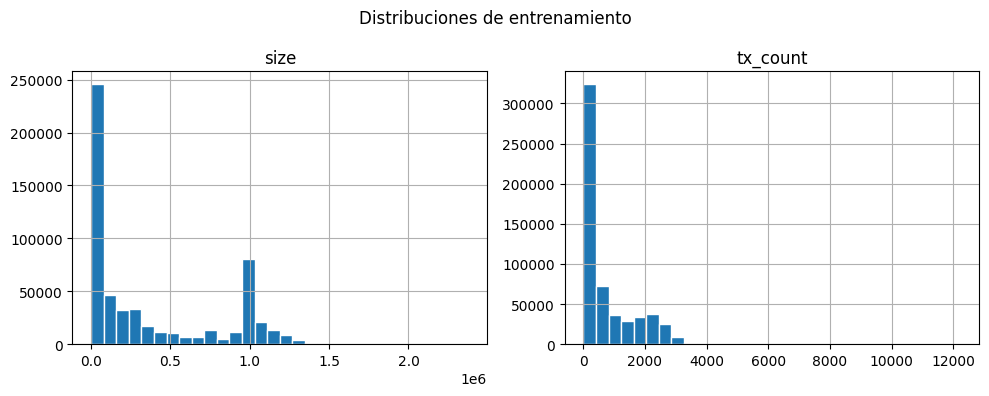

In [10]:
train[["size", "tx_count"]].hist(bins=30, figsize=(10, 4), edgecolor="white")
plt.suptitle("Distribuciones de entrenamiento")
plt.tight_layout()
plt.show()


La tasa mediana se grafica en su escala original para observar el efecto de los valores extremos.


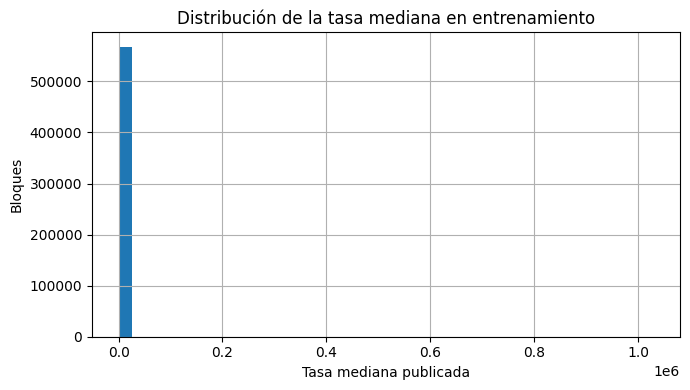

In [11]:
train["median_fee_rate"].hist(bins=40, figsize=(7, 4))
plt.xlabel("Tasa mediana publicada")
plt.ylabel("Bloques")
plt.title("Distribución de la tasa mediana en entrenamiento")
plt.tight_layout()
plt.show()


Unos pocos valores muy grandes extienden el eje horizontal y comprimen la mayor parte de los datos a la izquierda. Esto indica que hay que revisar los extremos; no justifica eliminarlos.

## 13. Tasas cero y bloques con una transacción

Un bloque con `tx_count = 1` contiene solo la transacción coinbase. No se elimina por ese motivo. Se comprueba si también hay tasas cero en bloques con más transacciones.


In [12]:
print("Bloques con una transacción:", (train["tx_count"] == 1).sum())
print("Bloques con tasa mediana cero:", (train["median_fee_rate"] == 0).sum())

con_varias_transacciones = train["tx_count"] > 1
con_tasa_cero = train["median_fee_rate"] == 0
print("Más de una transacción y tasa cero:", (con_varias_transacciones & con_tasa_cero).sum())

Bloques con una transacción: 88628
Bloques con tasa mediana cero: 177561
Más de una transacción y tasa cero: 88933


Existen bloques con varias transacciones y tasa mediana cero. Por eso, una tasa cero no identifica por sí sola un bloque con solo coinbase. Se conservan ambos casos; cero no se trata automáticamente como dato faltante.

## 14. Boxplots y valores extremos

El boxplot permite observar la mediana, la dispersión y los valores alejados del resto.


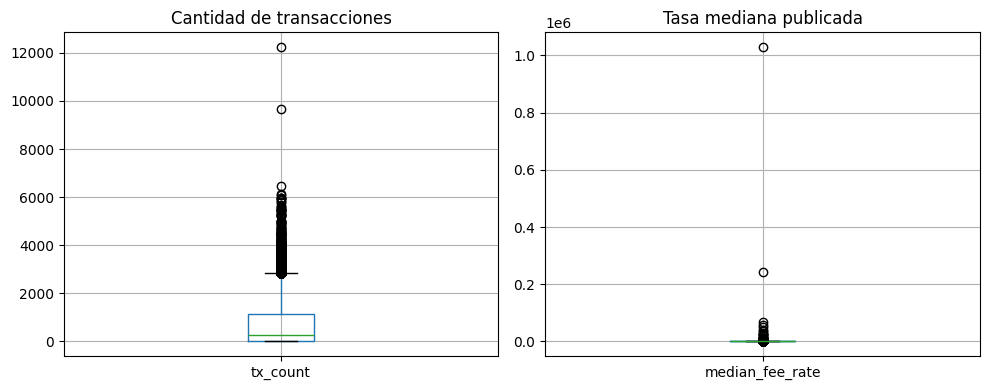

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train.boxplot(column="tx_count", ax=axes[0])
axes[0].set_title("Cantidad de transacciones")

train.boxplot(column="median_fee_rate", ax=axes[1])
axes[1].set_title("Tasa mediana publicada")

plt.tight_layout()
plt.show()

Se usa la regla del rango intercuartílico: `IQR = Q3 - Q1`. Los valores fuera de `Q1 - 1.5 × IQR` y `Q3 + 1.5 × IQR` se marcan para revisión, pero no se eliminan automáticamente.


In [14]:
q1 = train["median_fee_rate"].quantile(0.25)
q3 = train["median_fee_rate"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

extremos = train[(train["median_fee_rate"] < limite_inferior) |
                 (train["median_fee_rate"] > limite_superior)]

print("Límites IQR:", limite_inferior, limite_superior)
print("Bloques marcados:", len(extremos))
print("Porcentaje:", round(len(extremos) / len(train) * 100, 2))
extremos[["height", "median_fee_rate", "tx_count"]].nlargest(5, "median_fee_rate")

Límites IQR: -82.5 137.5
Bloques marcados: 54511
Porcentaje: 9.6


,height,median_fee_rate,tx_count
164383,164384,1029502.0,15
2816,2817,241545.0,4
71041,71042,68042.0,5
48889,48890,56155.0,2
164382,164383,50932.0,15


La regla marca 54 511 bloques de entrenamiento (9,60 %). Un extremo puede ser un dato real o una particularidad de la medición. Se conserva hasta contar con evidencia para corregirlo.

## 15. Variable objetivo y balance de clases

El percentil 75 de las tasas del siguiente bloque en entrenamiento define el umbral. Si la tasa supera ese valor, la clase es **1: alta**; en otro caso es **0: no alta**. La igualdad con el umbral pertenece a la clase 0.


In [15]:
umbral = train["tasa_siguiente"].quantile(0.75)
train["clase"] = (train["tasa_siguiente"] > umbral).astype(int)

print("Umbral:", umbral)
train[["height", "median_fee_rate", "tasa_siguiente", "clase"]].head()

Umbral: 55.0


,height,median_fee_rate,tasa_siguiente,clase
0,1,0.0,0.0,0
1,2,0.0,0.0,0
2,3,0.0,0.0,0
3,4,0.0,0.0,0
4,5,0.0,0.0,0


Porcentaje por clase:
clase
0    75.02
1    24.98
Name: count, dtype: float64


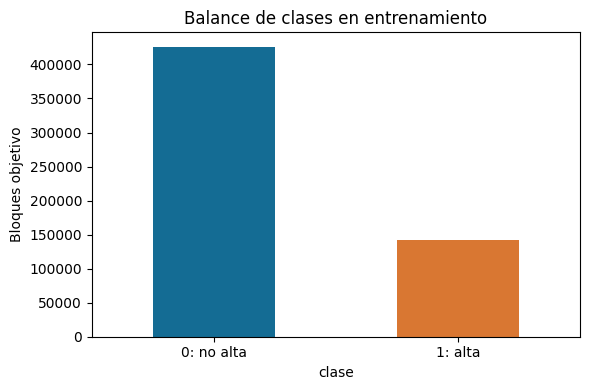

In [16]:
conteos = train["clase"].value_counts().sort_index()
porcentajes = conteos / len(train) * 100

print("Porcentaje por clase:")
print(porcentajes.round(2))

conteos.plot.bar(figsize=(6, 4), rot=0, color=["#146C94", "#D97732"])
plt.xticks([0, 1], ["0: no alta", "1: alta"])
plt.ylabel("Bloques objetivo")
plt.title("Balance de clases en entrenamiento")
plt.tight_layout()
plt.show()


El umbral es 55 en la escala publicada. La clase alta representa el 24,98 % de entrenamiento. Hay desbalance: predecir siempre «no alta» no demostraría que se identifican los bloques de comisión alta. La sección 9.1 comprueba si ese umbral mantiene su significado en las demás particiones.


### 15.1 ¿El umbral se traslada a validación y prueba?

El umbral se estimó con entrenamiento, que es lo correcto para evitar fuga de datos. Queda
por comprobar si la clase resultante mantiene una proporción comparable en las demás
particiones. Si la clase positiva casi desaparece en prueba, las métricas calculadas sobre
esa partición no serían informativas.

In [17]:
particiones = {"entrenamiento": train, "validacion": validacion, "prueba": prueba}

filas_balance = []
for nombre, parte in particiones.items():
    fechas = pd.to_datetime(parte["timestamp"], unit="ms", utc=True)
    filas_balance.append({
        "particion": nombre,
        "bloques": len(parte),
        "inicio": fechas.min().date(),
        "fin": fechas.max().date(),
        "mediana_tasa": parte["median_fee_rate"].median(),
        "pct_clase_alta": (parte["tasa_siguiente"] > umbral).mean() * 100,
    })

balance_particiones = pd.DataFrame(filas_balance).set_index("particion")
balance_particiones.round(2)

,bloques,inicio,fin,mediana_tasa,pct_clase_alta
particion,,,,,
entrenamiento,567635,2009-01-09,2019-03-18,17.0,24.98
validacion,121636,2019-03-18,2021-07-01,24.0,31.25
prueba,121637,2021-07-01,2023-10-06,8.0,2.31


La proporción de clase alta es 24,98 % en entrenamiento, 31,25 % en validación y **2,31 %
en prueba**.

Con ese balance, un clasificador que prediga siempre «no alta» obtendría 97,7 % de exactitud
en prueba sin haber aprendido nada. La partición de prueba, tal como está definida la clase,
no permite distinguir un modelo útil de uno trivial.

La causa no es un error de código. El umbral de 55 corresponde al percentil 75 de un
entrenamiento que abarca de 2009 a marzo de 2019, periodo en el que el 31,3 % de los bloques
tiene tasa mediana cero. La partición de prueba cubre de julio de 2021 a octubre de 2023,
cuando la tasa mediana típica es 8. El umbral no representa lo mismo en ambos periodos.

### 15.2 Evolución trimestral de la tasa frente al umbral fijo

El gráfico siguiente muestra la mediana trimestral de `median_fee_rate` junto con el umbral
de 55. Es una revisión estructural del archivo completo, del mismo tipo que las de la
sección 3; no se estima ningún parámetro a partir de validación o prueba.

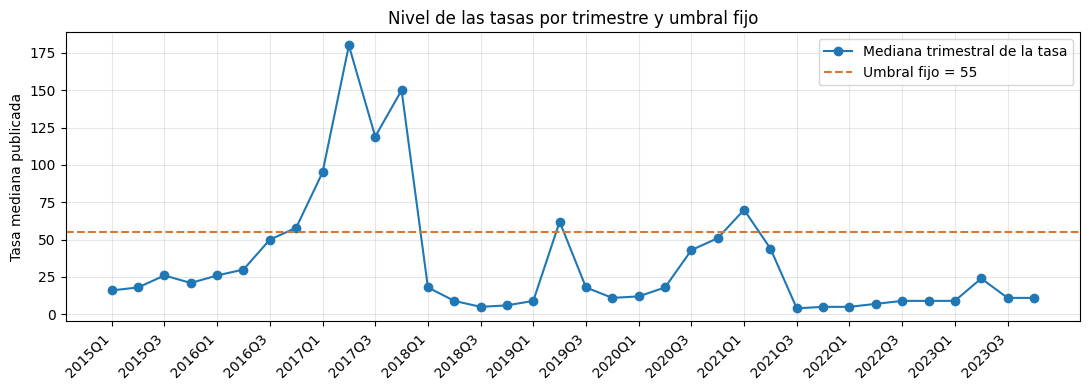

In [18]:
trimestre = pd.to_datetime(datos["timestamp"], unit="ms", utc=True).dt.tz_convert(None).dt.to_period("Q")
mediana_trimestral = datos[trimestre.dt.year >= 2015].groupby(
    trimestre[trimestre.dt.year >= 2015])["median_fee_rate"].median()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(len(mediana_trimestral)), mediana_trimestral.values,
        marker="o", label="Mediana trimestral de la tasa")
ax.axhline(umbral, color="#D97732", linestyle="--",
           label=f"Umbral fijo = {umbral:.0f}")

etiquetas = [str(p) for p in mediana_trimestral.index]
ax.set_xticks(range(0, len(etiquetas), 2))
ax.set_xticklabels(etiquetas[::2], rotation=45, ha="right")
ax.set_ylabel("Tasa mediana publicada")
ax.set_title("Nivel de las tasas por trimestre y umbral fijo")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Durante 2017 la mediana trimestral se mantiene por encima del umbral; desde el tercer
trimestre de 2021 permanece muy por debajo, con valores entre 4 y 11. Un umbral constante
no puede representar la misma noción de «tasa alta» a lo largo de todo el periodo.

### 15.3 Redefinición de la clase mediante un umbral móvil

Se conserva la idea original —la clase alta corresponde al 25 % de bloques con mayor tasa—
pero el percentil 75 se calcula sobre una ventana de bloques anteriores en lugar de sobre
todo el entrenamiento:

$$y_t = 1 \quad \text{si} \quad \text{tasa}_{t+1} > Q_{75}(\text{tasa}_{t-N+1}, \dots, \text{tasa}_t)$$

La ventana usa únicamente bloques hasta el actual, mientras que el objetivo corresponde al
bloque siguiente; por construcción no hay información del futuro. Se emplea N = 1008
bloques, equivalente a una semana aproximadamente, dado que un bloque se mina cada 10
minutos en promedio.

In [19]:
VENTANA = 1008  # bloques; una semana aproximadamente

datos["umbral_local"] = datos["median_fee_rate"].rolling(VENTANA).quantile(0.75)

movil = datos.dropna(subset=["tasa_siguiente", "umbral_local"]).reset_index(drop=True).copy()
movil["clase_movil"] = (movil["tasa_siguiente"] > movil["umbral_local"]).astype(int)

corte_train_m = int(len(movil) * 0.70)
corte_val_m = int(len(movil) * 0.85)

particiones_moviles = {
    "entrenamiento": movil.iloc[:corte_train_m],
    "validacion": movil.iloc[corte_train_m:corte_val_m],
    "prueba": movil.iloc[corte_val_m:],
}

filas_movil = []
for nombre, parte in particiones_moviles.items():
    fechas = pd.to_datetime(parte["timestamp"], unit="ms", utc=True)
    filas_movil.append({
        "particion": nombre,
        "bloques": len(parte),
        "inicio": fechas.min().date(),
        "fin": fechas.max().date(),
        "pct_clase_alta": parte["clase_movil"].mean() * 100,
    })

pd.DataFrame(filas_movil).set_index("particion").round(2)

,bloques,inicio,fin,pct_clase_alta
particion,,,,
entrenamiento,566930,2009-01-19,2019-03-20,17.40
validacion,121485,2019-03-20,2021-07-02,26.07
prueba,121486,2021-07-02,2023-10-06,23.18


Con el umbral móvil, la proporción de clase alta es 17,40 % en entrenamiento, 26,07 % en
validación y 23,18 % en prueba. La partición de prueba pasa de 2,31 % a 23,18 %: ya permite
evaluar un clasificador según la medida de desempeño definida en la sección 3.

La proporción de entrenamiento queda por debajo del 25 % porque en los primeros años muchos
bloques comparten tasa cero y la comparación estricta `>` no los cuenta como clase alta.

La clase deja de significar «tasa alta en términos históricos» y pasa a significar «tasa alta
respecto al nivel de la última semana». Es una definición más restrictiva en lo que afirma y más
útil en lo que responde: para decidir si conviene emitir una transacción ahora o esperar, importa
el nivel vigente, no la comparación con épocas pasadas.

Se comprueba la sensibilidad del resultado a la ventana elegida y al periodo de estudio.
El recorte posterior a SegWit (24 de agosto de 2017) se incluye porque ese cambio del
protocolo modificó la definición de la capacidad del bloque.

In [20]:
fecha_datos = pd.to_datetime(datos["timestamp"], unit="ms", utc=True)

filas_sensibilidad = []
for etiqueta_periodo, desde in [("completo", None), ("post-SegWit", "2017-08-24")]:
    base = datos if desde is None else datos[fecha_datos >= desde]
    for n_ventana in [144, 1008, 4320]:
        tramo = base.copy()
        tramo["u"] = tramo["median_fee_rate"].rolling(n_ventana).quantile(0.75)
        tramo = tramo.dropna(subset=["tasa_siguiente", "u"]).reset_index(drop=True)
        clase = (tramo["tasa_siguiente"] > tramo["u"]).astype(int)
        a, b = int(len(tramo) * 0.70), int(len(tramo) * 0.85)
        filas_sensibilidad.append({
            "periodo": etiqueta_periodo,
            "N": n_ventana,
            "train_%": clase[:a].mean() * 100,
            "val_%": clase[a:b].mean() * 100,
            "test_%": clase[b:].mean() * 100,
        })

pd.DataFrame(filas_sensibilidad).round(1)

,periodo,N,train_%,val_%,test_%
0,completo,144,17.6,25.6,21.8
1,completo,1008,17.4,26.1,23.2
2,completo,4320,18.3,25.3,24.3
3,post-SegWit,144,24.0,19.7,25.1
4,post-SegWit,1008,24.1,22.2,25.5
5,post-SegWit,4320,24.1,24.9,26.5


El balance entre particiones se mantiene estable para las tres ventanas, de modo que el resultado
no depende de la elección concreta de N. Se conserva N = 1008 porque una semana comprende un ciclo
completo de actividad: la red registra menos transacciones los fines de semana que en días
laborables.

El recorte posterior a SegWit se incluye en la tabla como referencia comparativa. No se aplica en
este análisis, que emplea el periodo completo; se reporta para documentar que la corrección del
desbalance procede de la definición móvil del umbral y no de la delimitación temporal.

## 16. Relaciones entre variables

Se utiliza la correlación de Pearson. Las entradas corresponden al bloque actual; `tasa_siguiente` corresponde al futuro y se incluye aquí solo para explorar su relación, nunca como entrada del modelo.


In [21]:
variables = ["size", "tx_count", "median_fee_rate", "total_fees", "tasa_siguiente"]
correlacion = train[variables].corr()
correlacion.round(3)


,size,tx_count,median_fee_rate,total_fees,tasa_siguiente
size,1.000,0.909,0.004,0.365,0.003
tx_count,0.909,1.000,0.008,0.393,0.005
median_fee_rate,0.004,0.008,1.000,0.179,0.050
total_fees,0.365,0.393,0.179,1.000,0.052
tasa_siguiente,0.003,0.005,0.050,0.052,1.000


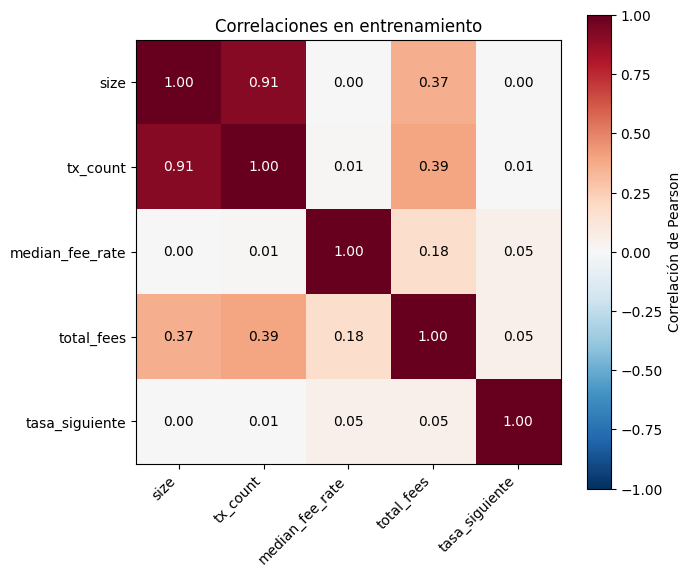

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
imagen = ax.imshow(correlacion, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(variables)), variables, rotation=45, ha="right")
ax.set_yticks(range(len(variables)), variables)

for i in range(len(variables)):
    for j in range(len(variables)):
        valor = correlacion.iloc[i, j]
        color = "white" if abs(valor) > 0.6 else "black"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color)

fig.colorbar(imagen, ax=ax, label="Correlación de Pearson")
ax.set_title("Correlaciones en entrenamiento")
plt.tight_layout()
plt.show()


La correlación lineal entre la tasa actual y la siguiente es aproximadamente 0,05. Una correlación baja no descarta relaciones no lineales ni demuestra que el problema sea impredecible. Los extremos también pueden afectar Pearson. La sección 16.1 examina ambas cuestiones.

Un diagrama de dispersión complementa la tabla. Se toma una muestra reproducible de 2 000 pares solo para facilitar la visualización; las estadísticas anteriores usan todo entrenamiento.


### 16.1 Correlación de rangos y correlación por época

La correlación de Pearson mide asociación **lineal** y es muy sensible a valores extremos.
La revisión de valores extremos mostró tasas de hasta 1 029 502 en la escala publicada, y la
evolución anual muestra que el nivel de las tasas cambia por completo entre años. Ambos efectos afectan a Pearson.

Se añade la correlación de **Spearman**, que trabaja sobre rangos y no se ve arrastrada por
unos pocos valores extremos, y se repite el cálculo separando el periodo en épocas.

In [23]:
correlacion_spearman = train[variables].corr(method="spearman")
correlacion_spearman.round(3)

,size,tx_count,median_fee_rate,total_fees,tasa_siguiente
size,1.000,0.969,0.568,0.880,0.504
tx_count,0.969,1.000,0.611,0.902,0.518
median_fee_rate,0.568,0.611,1.000,0.766,0.629
total_fees,0.880,0.902,0.766,1.000,0.612
tasa_siguiente,0.504,0.518,0.629,0.612,1.000


Con correlación de rangos, la asociación entre el tamaño del bloque y la tasa del siguiente
bloque pasa de 0,003 a 0,504, y la del número de transacciones, de 0,005 a 0,518. Las relaciones
existen, pero no son lineales en la escala original.

Estas asociaciones deben interpretarse con cautela. Parte de su magnitud procede de que ambas
variables separan épocas: los bloques del periodo temprano son pequeños y sus comisiones bajas,
mientras que los recientes son grandes y sus comisiones mayores. No es posible distinguir, con
este cálculo agregado, qué proporción corresponde a una relación dentro de un mismo régimen. La
sección 17.1 documenta el fenómeno y la sección 20 lo recoge como limitación.

A continuación se separa el periodo en épocas. Este cálculo es estructural y usa el archivo
completo; no estima ningún parámetro del modelo.

In [24]:
import numpy as np

fecha_completa = pd.to_datetime(datos["timestamp"], unit="ms", utc=True)

epocas = [("2009-2011", 2009, 2011), ("2012-2016", 2012, 2016),
          ("2017-2019", 2017, 2019), ("2020-2023", 2020, 2023)]

filas_epoca = []
for etiqueta, anio_inicio, anio_fin in epocas:
    en_epoca = (fecha_completa.dt.year >= anio_inicio) & (fecha_completa.dt.year <= anio_fin)
    tramo = datos[en_epoca].dropna(subset=["tasa_siguiente"])
    filas_epoca.append({
        "epoca": etiqueta,
        "bloques": len(tramo),
        "pearson": tramo["median_fee_rate"].corr(tramo["tasa_siguiente"]),
        "spearman": tramo["median_fee_rate"].corr(tramo["tasa_siguiente"], method="spearman"),
        "pearson_log": np.log1p(tramo["median_fee_rate"]).corr(np.log1p(tramo["tasa_siguiente"])),
    })

correlacion_por_epoca = pd.DataFrame(filas_epoca).set_index("epoca")
correlacion_por_epoca.round(3)

,bloques,pearson,spearman,pearson_log
epoca,,,,
2009-2011,160036,0.042,0.254,0.208
2012-2016,285996,0.049,0.354,0.212
2017-2019,164658,0.819,0.740,0.742
2020-2023,200218,0.817,0.692,0.718


La correlación entre la tasa actual y la siguiente es 0,042 en 2009-2011 y 0,049 en 2012-2016,
pero **0,819 en 2017-2019 y 0,817 en 2020-2023**.

El valor de 0,05 obtenido sobre todo el entrenamiento no describe una ausencia de relación:
resulta de mezclar un periodo sin competencia por espacio con otro donde sí la hay, y de la
influencia de los valores extremos de la era temprana. Dentro de cada época reciente la tasa del
bloque actual es un predictor fuerte de la del siguiente, lo que sustenta la hipótesis H1 y fija
una referencia exigente para la medida de desempeño P.

Este resultado es coherente con el diagnóstico de la sección 15.1 y con la caracterización de la
17.1.

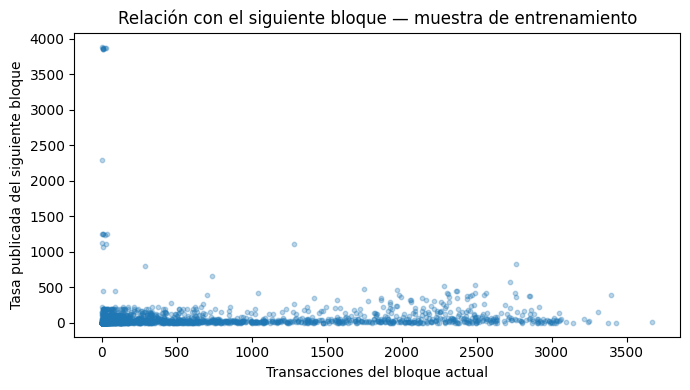

In [25]:
muestra = train.sample(2000, random_state=42)

plt.figure(figsize=(7, 4))
plt.scatter(muestra["tx_count"], muestra["tasa_siguiente"], s=10, alpha=0.3)
plt.xlabel("Transacciones del bloque actual")
plt.ylabel("Tasa publicada del siguiente bloque")
plt.title("Relación con el siguiente bloque — muestra de entrenamiento")
plt.tight_layout()
plt.show()


Las asociaciones observadas son descriptivas. No permiten atribuir causalidad ni anticipar el rendimiento de un clasificador. La evaluación de modelos se desarrollará posteriormente.


## 17. Evolución de las tasas por año

Se convierte `timestamp` a fecha, se obtiene el año y se agrupan los bloques de **entrenamiento**. Para cada año se calcula la mediana de `median_fee_rate`.

El resultado es la **mediana anual de las tasas publicadas por bloque**, no la mediana de todas las transacciones del año. La columna `bloques` indica cuántas observaciones aporta cada periodo.

Entrenamiento termina en marzo de 2019: ese año está incompleto. Validación y prueba no se utilizan en este gráfico.


In [26]:
anio = pd.to_datetime(train["timestamp"], unit="ms", utc=True).dt.year

evolucion_anual = train.groupby(anio)["median_fee_rate"].agg(["count", "median"])
evolucion_anual.columns = ["bloques", "mediana_tasa"]
evolucion_anual.index.name = "anio"

evolucion_anual


,bloques,mediana_tasa
anio,,
2009,32489,0.0
2010,67920,0.0
2011,59627,0.0
2012,54526,59.0
2013,63433,76.0
2014,58865,20.0
2015,54321,19.0
2016,54851,39.0
2017,55928,134.0


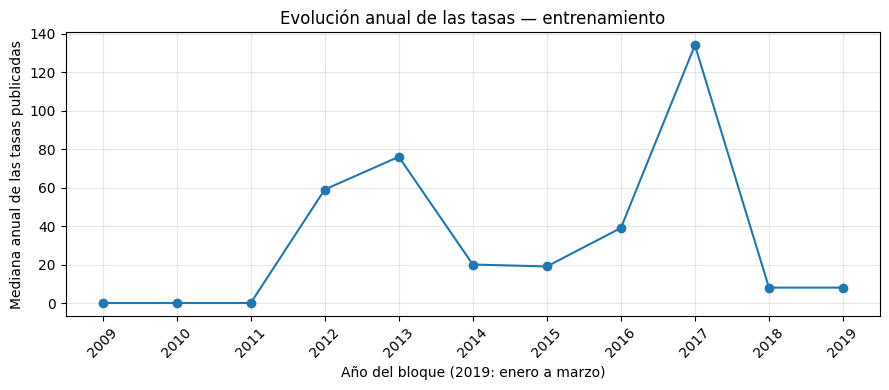

In [27]:
evolucion_anual["mediana_tasa"].plot(figsize=(9, 4), marker="o")
plt.xticks(evolucion_anual.index, rotation=45)
plt.xlabel("Año del bloque (2019: enero a marzo)")
plt.ylabel("Mediana anual de las tasas publicadas")
plt.title("Evolución anual de las tasas — entrenamiento")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


La mediana anual alcanza 134 en 2017 y baja a 8 en 2018, en la escala del dataset. Las tasas no mantienen el mismo nivel durante todo el periodo; esto respalda conservar el orden temporal al evaluar el modelo.

Una mediana anual de cero no significa que todos los bloques de ese año tengan tasa cero. Además, el gráfico describe cambios observados: por sí solo no explica sus causas ni predice el siguiente bloque.


### 17.1 Condiciones de formación del precio a lo largo del periodo

La sección anterior muestra que el nivel de las tasas cambia entre años. Interesa determinar
**por qué** cambia, porque de ello depende si el periodo completo describe un mismo fenómeno.

La comisión de una transacción se determina por competencia solo cuando el espacio en el bloque es
escaso. Si los bloques no se llenan, cualquier transacción entra y la comisión la fijan las reglas
del software cliente, no la demanda. Se mide entonces qué proporción de bloques de cada año se
acerca al límite de capacidad, junto con la persistencia de la tasa entre bloques consecutivos.

**La ocupación no es la variable objetivo.** Se analiza aquí porque es la condición que da origen
al mercado de comisiones, y por tanto determina si el fenómeno que el proyecto modela está
presente en cada tramo del periodo. Este cálculo usa el archivo completo y es estructural: no
estima ningún parámetro del modelo.

In [28]:
fecha_archivo = pd.to_datetime(df["timestamp"], unit="ms", utc=True)

filas_regimen = []
for anio_actual in range(2012, 2024):
    del_anio = df[fecha_archivo.dt.year == anio_actual]
    siguiente = del_anio["median_fee_rate"].shift(-1)
    filas_regimen.append({
        "anio": anio_actual,
        "bloques": len(del_anio),
        "pct_bloques_llenos": (del_anio["size"] > 900_000).mean() * 100,
        "pct_tasa_cero": (del_anio["median_fee_rate"] == 0).mean() * 100,
        "mediana_tasa": del_anio["median_fee_rate"].median(),
        "corr_con_siguiente": del_anio["median_fee_rate"].corr(siguiente),
    })

regimen_anual = pd.DataFrame(filas_regimen).set_index("anio")
regimen_anual.round(3)

,bloques,pct_bloques_llenos,pct_tasa_cero,mediana_tasa,corr_con_siguiente
anio,,,,,
2012,54526,0.000,37.199,59.0,0.049
2013,63433,0.043,7.094,76.0,0.020
2014,58865,1.145,4.497,20.0,0.090
2015,54321,16.820,6.362,19.0,0.124
2016,54851,62.781,2.126,39.0,0.205
2017,55928,89.252,1.025,134.0,0.702
2018,54498,66.059,0.872,8.0,0.866
2019,54232,79.484,0.625,16.0,0.743
2020,53222,87.522,0.490,21.0,0.719


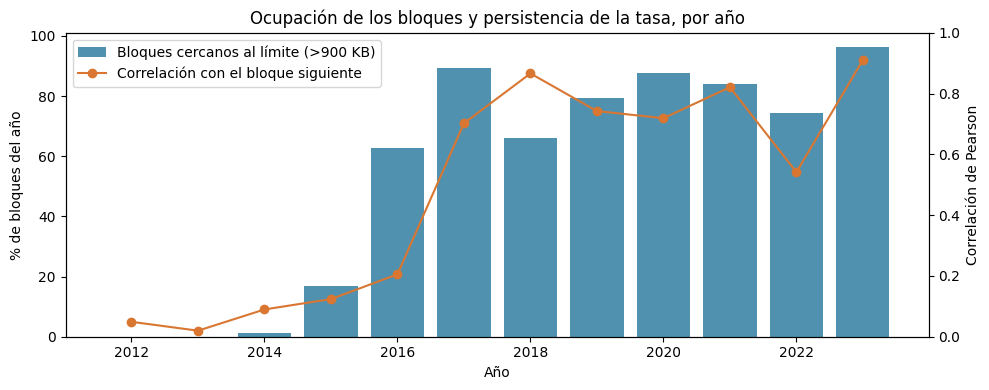

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(regimen_anual.index, regimen_anual["pct_bloques_llenos"],
        color="#146C94", alpha=0.75, label="Bloques cercanos al límite (>900 KB)")
ax1.set_ylabel("% de bloques del año")
ax1.set_xlabel("Año")

ax2 = ax1.twinx()
ax2.plot(regimen_anual.index, regimen_anual["corr_con_siguiente"],
         color="#D97732", marker="o", label="Correlación con el bloque siguiente")
ax2.set_ylabel("Correlación de Pearson")
ax2.set_ylim(0, 1)

ax1.set_title("Ocupación de los bloques y persistencia de la tasa, por año")
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left")
plt.tight_layout()
plt.show()

La proporción de bloques cercanos al límite pasa de 0,0 % en 2012 y 0,04 % en 2013 a 1,1 %
en 2014, 16,8 % en 2015 y 62,8 % en 2016, manteniéndose por encima del 66 % desde 2017. La
correlación entre la tasa de un bloque y la del siguiente sigue la misma trayectoria: 0,090 en
2014, 0,205 en 2016 y entre 0,54 y 0,91 a partir de 2017.

Ambas series describen el mismo hecho: **la escasez de espacio en bloque, y con ella la competencia
por comisión, se establece entre 2015 y 2016.** Existieron comisiones en Bitcoin desde 2009 —el
protocolo las contempla desde el diseño original— pero antes de ese punto no se determinaban por
competencia entre usuarios, sino por reglas fijas del software cliente.

El periodo analizado contiene por tanto dos mecanismos distintos de formación del precio. Esto se
recoge en la sección 20 como limitación y condiciona la interpretación de los resultados: un
modelo entrenado sobre el conjunto completo aprende de ambos regímenes, y su desempeño debe
evaluarse por tramos además de en agregado. La hipótesis H3 se formuló precisamente para
contrastar este punto.

## 18. Prevención de fuga de datos (data leakage)

La fuga de datos ocurre cuando el modelo accede, durante el entrenamiento, a información que no
estaría disponible en el momento de la predicción. Se aplican cuatro medidas explícitas:

1. **Partición temporal, no aleatoria.** Los bloques se ordenan por `height` y se cortan en tres
   tramos consecutivos. Una partición aleatoria permitiría entrenar con bloques posteriores a los
   evaluados.
2. **Umbral estimado solo con el pasado.** El umbral móvil de cada fila se calcula con la ventana
   de bloques anteriores a esa fila; nunca con bloques posteriores, ni con validación o prueba.
3. **Orientación del objetivo.** `tasa_siguiente` se obtiene con `shift(-1)`, de modo que
   corresponde al bloque posterior. Se utiliza únicamente como variable objetivo y nunca como
   entrada del modelo.
4. **Margen entre particiones.** Al construir variables con ventanas móviles, las primeras filas
   de validación y prueba reutilizan bloques del tramo anterior. Se descartará un margen del
   tamaño de la ventana más larga entre particiones, mediante el parámetro `gap` de
   `TimeSeriesSplit`.

**Nota sobre los diagnósticos de la sección 15.1.** El conteo de clases en validación y prueba se
realiza como revisión estructural del diseño experimental, del mismo tipo que la revisión de nulos
y duplicados sobre el archivo completo. No se estima ningún parámetro del modelo a partir de esas
particiones, ni se selecciona configuración alguna en función de su desempeño. Se declara
explícitamente para que la decisión quede auditable.

## 19. Siguientes pasos

**Construcción de variables derivadas.**

- Ocupación del bloque, normalizada por el máximo de una ventana móvil y no por el límite nominal
  de 1 MB, dado que SegWit (agosto de 2017) modificó la forma de medir la capacidad del bloque.
- Tiempo transcurrido entre bloques consecutivos, como indicador de acumulación de demanda sin
  procesar.
- Tamaño medio de transacción, entradas y salidas por transacción.
- Razón entre `avg_fee_rate` y `median_fee_rate`, como indicador de dispersión de las comisiones
  dentro del bloque: un valor elevado señala que algunas transacciones pagaron muy por encima del
  resto.
- Rezagos y ventanas móviles de la tasa mediana.
- Variables de calendario: hora del día y día de la semana.

**Modelado y evaluación.**

- Referencia de persistencia: predecir para el bloque siguiente la clase observada en el actual.
  Ningún modelo se considerará útil si no la supera.
- Regresión logística con regularización como modelo principal, por su interpretabilidad y por
  corresponder al contenido del curso.
- Validación con ventana expansiva (`TimeSeriesSplit` con `gap` igual a la ventana más larga
  empleada en las variables derivadas), reportando media y desviación entre pliegues.
- Métricas de la sección 3: F1 sobre la clase alta y PR-AUC. La exactitud se reportará únicamente
  como referencia secundaria.
- **Contraste de H3:** evaluación segmentada por tramo del periodo, comparando el desempeño en los
  años previos a 2016 con el de los posteriores. Este análisis determina si la heterogeneidad
  documentada en la sección 17.1 afecta la capacidad predictiva del modelo.

## 20. Limitaciones

- **Heterogeneidad del periodo.** El conjunto de datos abarca dos mecanismos distintos de
  formación del precio (sección 17.1). Un modelo entrenado sobre todo el periodo aprende de ambos,
  y las relaciones observadas en agregado pueden no corresponder a las vigentes en cada uno.
- **Atribución de las correlaciones.** Las asociaciones entre tamaño de bloque, número de
  transacciones y el objetivo (sección 16.1) reflejan en parte la separación entre épocas y no
  únicamente una relación dentro de un mismo régimen.
- **Ausencia del mempool.** No se dispone del estado de la cola de transacciones pendientes, que
  es información central en la literatura sobre estimación de comisiones. La congestión se
  aproxima mediante la ocupación de los bloques.
- **Sesgo de selección.** Solo se observan transacciones confirmadas. Las ofertas insuficientes no
  quedan registradas, de modo que se observa el resultado de la subasta y no el conjunto de
  ofertas.
- **Agregación.** Los resultados describen el comportamiento del mercado y no permiten inferencia
  directa sobre transacciones individuales.
- **Inconsistencias de la fuente.** 2 512 bloques presentan la mediana fuera del rango publicado
  (sección 9.2).
- **Dependencia entre observaciones.** Los bloques consecutivos están separados por unos diez
  minutos y son fuertemente dependientes entre sí. El tamaño de muestra efectivo es menor que el
  nominal, por lo que diferencias pequeñas entre modelos no serán concluyentes.

## Referencias

- Jesús Graterol. [Bitcoin Blockchain Historical Data](https://www.kaggle.com/datasets/jesusgraterol/bitcoin-blockchain-dataset), Kaggle.
- Jesús Graterol. [Generador y esquema del dataset](https://github.com/jesusgraterol/bitcoin-blockchain-dataset-builder).
- Bitcoin Developer Documentation. [Block Chain](https://developer.bitcoin.org/reference/block_chain.html), transacción coinbase.
